# Scores across conditions

`build_scores.py` scores every condition from the move logs and returns one long
DataFrame, one row per participant-round. It also writes `scores_<condition>.csv` per
condition and `scores_all.csv` combined.

Two things it fixes that a plain `score_from_logs.py --dir` cannot:

- **Conditions that share a directory.** Phase 2's vanilla, v2 and v9 arms are told apart
  by `intervention.json`, not by folder.
- **The `ai` flag.** Every copy of `score_from_logs.py` hardcodes R1 as assisted, but the
  two baseline studies played R1 with no assistant at all.

**No exclusions are baked in.** The columns that define the population are carried instead
— `carryover`, `reached_demographics`, `prompt_rule`, `prompt_mean_score`, `prompt_passed`,
`effort_median` — so each analysis applies its own. Filtering
`~carryover & reached_demographics` reproduces the phase-2 analysis set.

In [27]:
import glob

# Adopter no-AI baseline: Baseline dir, /Users/siyanli/Documents/CITRUS/game_user_study_baseline_othello, under recordings-download-adopters
# Adopters vanilla AI: /Users/siyanli/Documents/CITRUS/game_user_study_phase_othello , recordings-download
# Non-adopters no-AI baseline: /Users/siyanli/Documents/CITRUS/game_user_study_baseline_othello, under recordings-download
# Non-adopters vanilla AI: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , vanilla (having no intervention.json but demographics.json)
# Non-adopters intervention v2: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , has intervention.json and demographics.json, and intervention variant is v2
# Non-adopters intervention v9: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , has intervention.json and demographics.json, and intervention variant is v9
# Non-adopters intervention johnny: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-download
# Non-adopters intervention modelled-ta: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-modelled-ta
# Non-adopters intervention esr: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-esr

In [28]:
import importlib

import build_scores
build = importlib.reload(build_scores).build   # the kernel caches this module, and a stale
                                              # copy rewrites the CSVs from whatever
                                              # condition list it was imported with

# write=True also refreshes the per-condition CSVs and scores_all.csv
df = build()
df.shape


condition                 population     participants  R1 rounds  both solo rounds
baseline_adopters         adopters                100        100               100
vanilla_adopters          adopters                111        110               110
baseline_non_adopters     non-adopters             50         50                50
vanilla_non_adopters      non-adopters             38         38                38
intervention_v2           non-adopters             25         25                25
intervention_v9           non-adopters             15         15                15
intervention_johnny       non-adopters             21         21                 0
intervention_modelled_ta  non-adopters             15         15                 0
intervention_esr          non-adopters             14         14                 0
3arm_vanilla              non-adopters             19         19                19   -> pooled into vanilla_non_adopters
3arm_johnny               non-adopters           

(1232, 53)

## R1 (assisted round) by condition

The three newest interventions ran assisted-only, so they have **no R2/R3 rows** — any
transfer comparison covers the six older conditions only.

In [29]:
r1 = df[(df["round"] == "R1") & ~df.carryover & df.reached_demographics].copy()
r1["optimal_pct"] = 100 * r1.score / r1.decisions

(r1.groupby(["population", "condition"])
   .agg(n=("pid", "nunique"), optimal_pct=("optimal_pct", "mean"),
        margin_mean=("margin", "mean"), margin_median=("margin", "median"),
        solved=("solved", "sum"), ai_turns=("ai_turns", "mean"))
   .round(1))

n  optimal_pct  margin_mean  \
population   condition                                                 
adopters     baseline_adopters         100         43.2        -21.0   
             vanilla_adopters          110         69.3         -8.6   
non-adopters 3arm_v9_reasons            23         77.0         -4.2   
             baseline_non_adopters      50         35.4        -22.2   
             intervention_esr           14         67.1        -13.8   
             intervention_johnny        34         75.5         -4.4   
             intervention_modelled_ta   15         61.3        -12.4   
             intervention_v2            16         72.2         -7.5   
             intervention_v9            15         71.1         -4.5   
             vanilla_non_adopters       48         68.9         -8.7   

                                       margin_median  solved  ai_turns  
population   condition                                                  
adopters     baseline_adopters                 -22.0       0       0.0  
             vanilla_adopters                  -18.0      20       5.5  
non-adopters 3arm_v9_reasons                    -4.0       8       5.5  
             baseline_non_adopters             -22.0       0       0.0  
             intervention_esr                  -18.0       1       5.5  
             intervention_johnny                -4.0      11       5.4  
             intervention_modelled_ta          -20.0       2       5.8  
             intervention_v2                   -14.0       3       5.2  
             intervention_v9                   -18.0       6       6.4  
             vanilla_non_adopters              -18.0       8       5.4

## Transfer block — summed margin over the two unassisted rounds

Only the conditions that ran solo rounds appear; the three newest interventions ran assisted-only.


In [30]:
# Total margin across the two unassisted rounds, one value per participant.
# Only participants who completed BOTH are counted -- summing over one round would put them
# on a different scale. `margin` is None for a round that timed out with squares still
# empty (a position, not a result), so those participants drop out here.
solo = df[df.transfer & ~df.carryover & df.reached_demographics]

solo_margin = (solo.groupby(["population", "condition", "pid"])["margin"]
                   .agg(["sum", "count"])
                   .query("count == 2")["sum"]
                   .rename("solo_margin")
                   .reset_index())

(solo_margin.groupby(["population", "condition"])["solo_margin"]
            .agg(n="size", mean="mean", median="median", sd="std",
                 min="min", max="max")
            .round(2))

n   mean  median     sd   min   max
population   condition                                                   
adopters     baseline_adopters      100 -15.30   -15.0  12.49 -40.0  16.0
             vanilla_adopters       107 -13.53   -14.0  11.57 -34.0  16.0
non-adopters 3arm_v9_reasons         23 -15.57   -14.0  10.65 -34.0   4.0
             baseline_non_adopters   50 -18.36   -21.0  11.71 -38.0  16.0
             intervention_johnny     13 -14.31   -14.0  12.98 -32.0  16.0
             intervention_v2         16 -18.62   -20.0  10.24 -36.0   4.0
             intervention_v9         15 -14.53   -14.0  12.29 -38.0   6.0
             vanilla_non_adopters    47 -13.32   -14.0  15.48 -40.0  16.0

## Margin distributions

One dot per participant, identical values stacked, so the **bimodality** is visible: people
who finish the position land at the ceiling (+18 in R1, +16 across both solo rounds) and the
rest cluster near −20. That is why a condition mean is close to a re-encoding of its solve
rate, and why the median tick sits where it does.

Colour marks whether the CONDITION had an assisted round — in the right-hand panel nobody
has an assistant, so the colours there identify the condition, not the round.

## Split into one DataFrame per condition

In [31]:
import pandas as pd

# One DataFrame per condition, each already filtered to the analysis set
# (fresh recruits who reached the demographics page). Everything below works from these
# rather than from `df`, so a condition can be inspected or swapped on its own.
ORDER = ["baseline_adopters", "vanilla_adopters",
         "baseline_non_adopters", "vanilla_non_adopters",
         "intervention_v2", "intervention_v9",
         "intervention_johnny", "intervention_modelled_ta", "intervention_esr",
         "3arm_v9_reasons"]

analysed = df[~df.carryover & df.reached_demographics]
dfs = {c: analysed[analysed.condition == c].copy() for c in ORDER}

# Named handles for poking at one condition directly.
df_baseline_adopters     = dfs["baseline_adopters"]
df_vanilla_adopters      = dfs["vanilla_adopters"]
df_baseline_non_adopters = dfs["baseline_non_adopters"]
df_vanilla_non_adopters  = dfs["vanilla_non_adopters"]
df_v2                    = dfs["intervention_v2"]
df_v9                    = dfs["intervention_v9"]
df_johnny                = dfs["intervention_johnny"]
df_modelled_ta           = dfs["intervention_modelled_ta"]
df_esr                   = dfs["intervention_esr"]
# 3-arm contrasting-cases arm. Stands on its own rather than pooling into
# intervention_v9: same family, different variant (v9_reasons vs v9_two_rows).
df_v9_reasons            = dfs["3arm_v9_reasons"]

# R1 row and summed solo margin, per condition.
r1s = {c: d[d["round"] == "R1"] for c, d in dfs.items()}
solos = {c: (d[d.transfer].groupby("pid").margin.agg(["sum", "size"])
              .query("size == 2")["sum"])
         for c, d in dfs.items()}

pd.DataFrame({"participants": {c: d.pid.nunique() for c, d in dfs.items()},
              "R1 rows": {c: len(v) for c, v in r1s.items()},
              "both solo rounds": {c: len(v) for c, v in solos.items()}}).loc[ORDER]

,participants,R1 rows,both solo rounds
baseline_adopters,100,100,100
vanilla_adopters,111,110,110
baseline_non_adopters,50,50,50
vanilla_non_adopters,48,48,48
intervention_v2,16,16,16
intervention_v9,15,15,15
intervention_johnny,34,34,13
intervention_modelled_ta,15,15,0
intervention_esr,14,14,0
3arm_v9_reasons,23,23,23


## Sensitivity: dropping johnny's late batch


In [32]:
# --- explicit exclusion: johnny's late batch -------------------------------------
# The 5 johnny participants who consented at ~20:00-21:00 UTC on 2026-08-20 are dropped,
# on the grounds that they were recruited late in the day and may be a different slice of
# the pool from the 01:00 batch.
#
# Scoped on `batch`, not on `condition`: intervention_johnny now also holds the 3-arm
# batch (consented 2026-08-21), and an open-ended cut at 2026-08-20T18 would drop all 13
# of those as well.
#
# STATE THIS IF IT IS REPORTED. The exclusion is correlated with the outcome -- this is the
# batch that pulled johnny's R1 optimal rate from 75.4 to 71.2 -- and it is not applied
# symmetrically: every other condition also sits in one narrow recruitment window
# (modelled_TA is entirely hour 02, v9 is one day, the baselines span other hours) and none
# of those are dropped. Keep DROP_LATE_JOHNNY = False as the primary analysis and use
# True only as a stated sensitivity check.
DROP_LATE_JOHNNY = True

def late_johnny(d):
    return ((d.batch == "intervention_johnny")
            & (d.consented_at.fillna("") >= "2026-08-20T18"))

print(f"late johnny batch: {df.loc[late_johnny(df), 'pid'].nunique()} participants")

analysed = df[~df.carryover & df.reached_demographics]
if DROP_LATE_JOHNNY:
    analysed = analysed[~late_johnny(analysed)]

r1x = analysed[analysed["round"] == "R1"].copy()
r1x["optimal_pct"] = 100 * r1x.score / r1x.decisions

both = []
for label, keep in (("with late batch", False), ("without late batch", True)):
    a = df[~df.carryover & df.reached_demographics]
    if keep:
        a = a[~late_johnny(a)]
    g = a[(a["round"] == "R1") & (a.condition == "intervention_johnny")]
    both.append({"version": label, "n": len(g),
                 "R1 optimal %": round(100 * g.score.sum() / g.decisions.sum(), 1),
                 "R1 optimal % (mean of persons)": round((100 * g.score / g.decisions).mean(), 1),
                 "margin mean": round(g.margin.mean(), 1),
                 "solved": f"{int(g.solved.sum())}/{len(g)}"})


late johnny batch: 6 participants


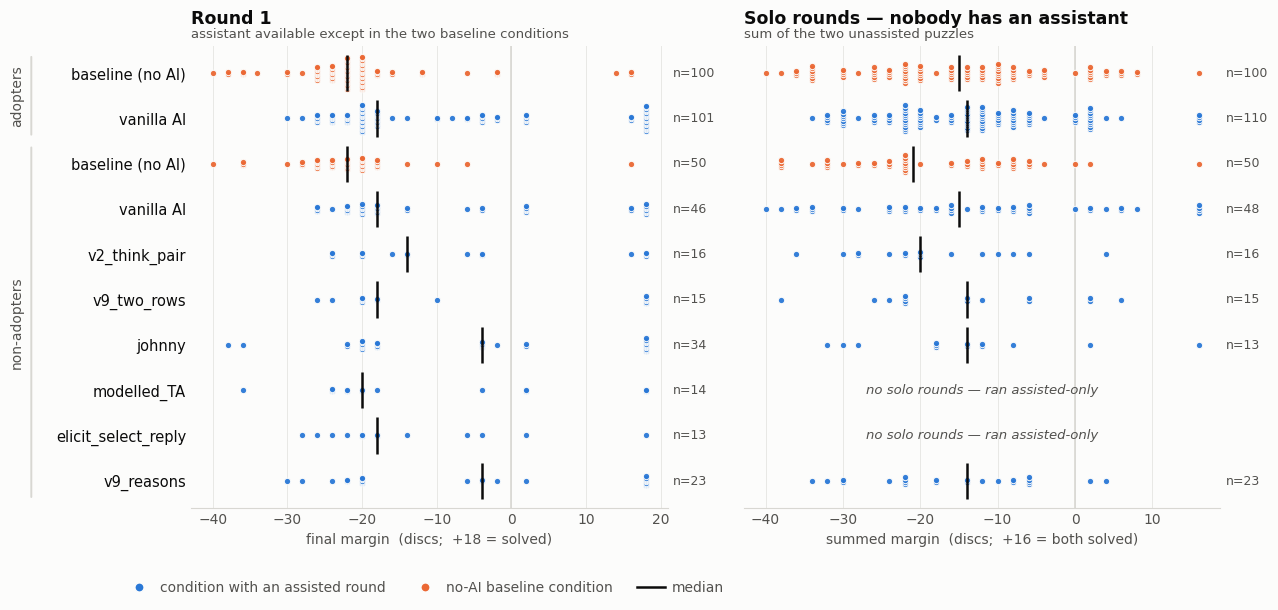

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Slots 1-2 of the reference categorical palette. Identity is carried by the y-axis, so
# colour encodes only one thing: whether the CONDITION included an assisted round.
AI_ON, AI_OFF = "#2a78d6", "#eb6834"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#d8d7d2", "#fcfcfb"

keep = ~df.carryover & df.reached_demographics
ORDER = ["baseline_adopters", "vanilla_adopters",
         "baseline_non_adopters", "vanilla_non_adopters",
         "intervention_v2", "intervention_v9",
         "intervention_johnny", "intervention_modelled_ta", "intervention_esr",
         "3arm_v9_reasons"]
LABEL = {"baseline_adopters": "baseline (no AI)", "vanilla_adopters": "vanilla AI",
         "baseline_non_adopters": "baseline (no AI)", "vanilla_non_adopters": "vanilla AI",
         "intervention_v2": "v2_think_pair", "intervention_v9": "v9_two_rows",
         "intervention_johnny": "johnny", "intervention_modelled_ta": "modelled_TA",
         "intervention_esr": "elicit_select_reply",
         "3arm_v9_reasons": "v9_reasons"}

r1 = df[keep & (df["round"] == "R1")]
solo = df[keep & df.transfer]
ss = (solo.groupby(["condition", "pid"]).margin.agg(["sum", "size"])
          .query("size == 2")["sum"].reset_index())
HAS_AI = {c: bool(r1[r1.condition == c].ai.iloc[0]) for c in ORDER
          if len(r1[r1.condition == c])}

R1V = {c: r1[r1.condition == c].margin.dropna().tolist() for c in ORDER}
SOV = {c: ss[ss.condition == c]["sum"].tolist() for c in ORDER}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.6), sharey=True,
                         gridspec_kw={"wspace": 0.16})
fig.patch.set_facecolor(SURF)


def strip(ax, data, title, note, xlabel):
    # One step size for the whole panel, sized so the tallest column of identical
    # values still fits inside its row. Stacks are CENTRED, so they cannot climb into
    # the row above -- the bug in the first draft.
    tallest = max((max(Counter(v).values()) for v in data.values() if v), default=1)
    step = min(0.052, 0.74 / max(tallest, 1))
    for i, cond in enumerate(ORDER):
        y0, vals = -i, data.get(cond)
        if not vals:
            ax.text(0.5, y0, "no solo rounds — ran assisted-only", va="center",
                    ha="center", color=INK2, fontsize=9.5, style="italic",
                    transform=ax.get_yaxis_transform(which="grid"))
            continue
        c = AI_ON if HAS_AI.get(cond) else AI_OFF
        counts = Counter(vals)
        for v in sorted(counts):
            n = counts[v]
            for k in range(n):
                ax.plot(v, y0 + (k - (n - 1) / 2) * step, "o", ms=4.6, color=c,
                        mec=SURF, mew=0.8, alpha=.95, zorder=3)
        med = float(np.median(vals))
        ax.plot([med, med], [y0 - 0.40, y0 + 0.40], color=INK, lw=1.8, zorder=4,
                solid_capstyle="butt")
        # n outside the axes, so it can never sit on top of a mark
        ax.annotate(f"n={len(vals)}", xy=(1.012, y0), xycoords=("axes fraction", "data"),
                    va="center", ha="left", color=INK2, fontsize=9, annotation_clip=False)
    ax.axvline(0, color=GRID, lw=1.2, zorder=1)
    ax.set_title(title, color=INK, fontsize=12.5, loc="left", pad=16, fontweight="600")
    ax.text(0, 1.012, note, transform=ax.transAxes, color=INK2, fontsize=9.5, va="bottom")
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_facecolor(SURF)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK2, length=0, labelsize=10)
    ax.grid(axis="x", color=GRID, lw=.7, alpha=.55, zorder=0)
    ax.set_axisbelow(True)


strip(axes[0], R1V, "Round 1",
      "assistant available except in the two baseline conditions",
      "final margin  (discs;  +18 = solved)")
strip(axes[1], SOV, "Solo rounds — nobody has an assistant",
      "sum of the two unassisted puzzles",
      "summed margin  (discs;  +16 = both solved)")

axes[0].set_yticks([-i for i in range(len(ORDER))], [LABEL[c] for c in ORDER], fontsize=10.5)
for t in axes[0].get_yticklabels():
    t.set_color(INK)
axes[0].set_ylim(-len(ORDER) + 0.4, 0.6)

for lab, i0, i1 in (("adopters", 0, 1), ("non-adopters", 2, 9)):
    axes[0].annotate("", xy=(-0.335, -i0 + 0.42), xytext=(-0.335, -i1 - 0.42),
                     xycoords=("axes fraction", "data"),
                     arrowprops=dict(arrowstyle="-", color=GRID, lw=1.4),
                     annotation_clip=False)
    axes[0].annotate(lab, xy=(-0.365, -(i0 + i1) / 2), xycoords=("axes fraction", "data"),
                     rotation=90, va="center", ha="center", color=INK2, fontsize=10,
                     annotation_clip=False)

h = [plt.Line2D([], [], marker="o", ls="", ms=6.5, color=AI_ON, mec=SURF, mew=.9),
     plt.Line2D([], [], marker="o", ls="", ms=6.5, color=AI_OFF, mec=SURF, mew=.9),
     plt.Line2D([], [], color=INK, lw=1.8)]
fig.legend(h, ["condition with an assisted round", "no-AI baseline condition", "median"],
           loc="lower left", bbox_to_anchor=(0.145, 0.005), ncol=3, frameon=False,
           fontsize=10, labelcolor=INK2, handletextpad=.5, columnspacing=1.8)
fig.subplots_adjust(left=0.20, right=0.925, top=0.855, bottom=0.155)
plt.show()


In [34]:
df_baseline_adopters.columns

Index(['condition', 'batch', 'population', 'pid', 'round', 'puzzle', 'ai',
       'transfer', 'form', 'variant', 'consented_at', 'pretask_at',
       'prompt_rule', 'prompt_mean_score', 'prompt_passed', 'carryover',
       'reached_demographics', 'effort_median', 'skill_rating', 'age',
       'education', 'genai_usage', 'gate_correct', 'gate_confidence',
       'ai_turns', 'end_reason', 'decisions', 'score', 'decisions_first_n',
       'score_first_n', 'kept_win_score', 'kept_win_first_n', 'opener_optimal',
       'disc_loss_total', 'disc_loss_per_decision', 'seconds', 'completed',
       'black_discs', 'white_discs', 'margin', 'won', 'moves', 'attempts',
       'solved', 'transfer_rounds', 'transfer_score', 'transfer_decisions',
       'transfer_rate', 'transfer_wins', 'transfer_solved', 'transfer_openers',
       'transfer_disc_loss', 'transfer_label'],
      dtype='object')

# Baseline adopters and baseline non-adopters are the same on R1, R2 (?), R3

In [35]:
from scipy.stats import mannwhitneyu
import numpy as np

for r in ["R1", "R2", "R3"]:
    curr_round_adopter = df_baseline_adopters.loc[df_baseline_adopters["round"] == r]["margin"].to_list()
    curr_round_non_adopter = df_baseline_non_adopters.loc[df_baseline_non_adopters["round"] == r]["margin"].to_list()
    print("EVALUATING:   ", r)
    print("\t Adopters:", np.mean(curr_round_adopter))
    print("\t Non-Adopters:", np.mean(curr_round_non_adopter))
    print(mannwhitneyu(curr_round_adopter, curr_round_non_adopter))

EVALUATING:    R1
	 Adopters: -20.96
	 Non-Adopters: -22.16
MannwhitneyuResult(statistic=np.float64(2668.0), pvalue=np.float64(0.49790952956643286))
EVALUATING:    R2
	 Adopters: -3.36
	 Non-Adopters: -6.32
MannwhitneyuResult(statistic=np.float64(2968.0), pvalue=np.float64(0.05672255799645577))
EVALUATING:    R3
	 Adopters: -11.94
	 Non-Adopters: -12.04
MannwhitneyuResult(statistic=np.float64(2503.5), pvalue=np.float64(0.9903625243426408))


# Vanilla Adopters are around the same as vanilla non-adopters

In [36]:

for r in ["R1", "R2", "R3"]:
    curr_round_adopter = df_vanilla_adopters.loc[df_vanilla_adopters["round"] == r]["margin"].dropna().to_list()
    curr_round_non_adopter = df_vanilla_non_adopters.loc[df_vanilla_non_adopters["round"] == r]["margin"].dropna().to_list()
    print("EVALUATING:   ", r)
    print("\t Adopters:", np.mean(curr_round_adopter), np.median(curr_round_adopter))
    print("\t Non-Adopters:", np.mean(curr_round_non_adopter), np.median(curr_round_non_adopter))
    print(mannwhitneyu(curr_round_adopter, curr_round_non_adopter))

EVALUATING:    R1
	 Adopters: -8.633663366336634 -18.0
	 Non-Adopters: -8.73913043478261 -18.0
MannwhitneyuResult(statistic=np.float64(2318.5), pvalue=np.float64(0.9865370393438933))
EVALUATING:    R2
	 Adopters: -3.196261682242991 -2.0
	 Non-Adopters: -1.5833333333333333 -2.0
MannwhitneyuResult(statistic=np.float64(2426.5), pvalue=np.float64(0.5773852345392789))
EVALUATING:    R3
	 Adopters: -10.414414414414415 -10.0
	 Non-Adopters: -12.085106382978724 -12.0
MannwhitneyuResult(statistic=np.float64(2904.5), pvalue=np.float64(0.25493730644757207))


# Are Interventions producing better scores?

In [37]:
for labe, interv in [
    ("v2", df_v2),
    ("v9", df_v9),
    ("johnny", df_johnny),
    ("esr", df_esr),
    ("model", df_modelled_ta),
    ("v9_reasons", df_v9_reasons)]:
    print("Evaluating: ", labe)
    curr_round_vanilla = df_vanilla_non_adopters.loc[df_vanilla_non_adopters["round"] == "R1"]["margin"].dropna().to_list()
    curr_round_interv = interv.loc[interv["round"] == "R1"]["margin"].dropna().to_list()
    print("\t Vanilla:", np.mean(curr_round_vanilla), np.median(curr_round_vanilla), len(curr_round_vanilla))
    print("\t Intervention:", np.mean(curr_round_interv), np.median(curr_round_interv), len(curr_round_interv))
    print(mannwhitneyu(curr_round_vanilla, curr_round_interv))


Evaluating:  v2
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: -7.5 -14.0 16
MannwhitneyuResult(statistic=np.float64(346.0), pvalue=np.float64(0.7274641937634055))
Evaluating:  v9
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: -4.533333333333333 -18.0 15
MannwhitneyuResult(statistic=np.float64(298.5), pvalue=np.float64(0.4352864576468436))
Evaluating:  johnny
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: -4.411764705882353 -4.0 34
MannwhitneyuResult(statistic=np.float64(643.0), pvalue=np.float64(0.17222193147613174))
Evaluating:  esr
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: -13.846153846153847 -18.0 13
MannwhitneyuResult(statistic=np.float64(347.5), pvalue=np.float64(0.37634067974186425))
Evaluating:  model
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: -12.428571428571429 -20.0 14
MannwhitneyuResult(statistic=np.float64(381.0), pvalue=np.float64(0.3026433151603979))
Evaluating:  v9_reasons
	 Vanilla: -8.73913043478261 -18.0 46
	 Intervention: 

# Do Non-Adopters with AI transfer better?

In [38]:
# Total solo margin per participant (R2 + R3 summed) rather than the two rounds
# separately. Only participants who completed BOTH are counted -- summing over one round
# would put them on a different scale from everyone else.
def total_solo(d):
    s = (d.loc[d.transfer].groupby("pid")["margin"]
           .agg(["sum", "count"]))
    return s.loc[s["count"] == 2, "sum"]

curr_vanilla  = total_solo(df_vanilla_non_adopters).to_list()
curr_baseline = total_solo(df_baseline_non_adopters).to_list()

print("EVALUATING Non-Adopters:    total solo margin (R2+R3)")
print("\t Vanilla: ", np.mean(curr_vanilla), np.median(curr_vanilla), f"n={len(curr_vanilla)}")
print("\t Baseline:", np.mean(curr_baseline), np.median(curr_baseline), f"n={len(curr_baseline)}")
print(mannwhitneyu(curr_vanilla, curr_baseline))

EVALUATING Non-Adopters:    total solo margin (R2+R3)
	 Vanilla:  -13.319148936170214 -14.0 n=47
	 Baseline: -18.36 -21.0 n=50
MannwhitneyuResult(statistic=np.float64(1390.0), pvalue=np.float64(0.12078400175129125))


# Effect sizes

`mannwhitneyu` answers "could this gap be noise?" and nothing else — its p-value confounds
the size of the gap with n, so it cannot say whether an arm is *worth shipping*. That needs
an effect size, reported with a confidence interval.

**Use the rank-based one.** The margin distribution here is bimodal (ceiling at +18, the
rest near −20), so a standardised mean difference like Cohen's d is misleading: d divides
by an SD that describes no one, because nobody sits near the mean. The effect size that
pairs with Mann-Whitney is the **rank-biserial correlation**, which equals **Cliff's
delta** and is a direct rescaling of the U statistic:

```
delta = 2U / (n1 * n2) - 1
```

It reads as a probability, which is what makes it reportable: `delta = 0.30` means a
randomly drawn participant from arm A beats a randomly drawn one from arm B 65% of the
time (`P(sup) = (delta + 1) / 2`). It is invariant to the bimodality, needs no
distributional assumption, and is defined even when both arms pile up on the same two
values.

**The CI matters more than the point estimate at these n.** Arms here run 14–35
participants, and §3 of `NOTES_intervention_iteration.md` puts the transfer outcome's
reliability at 0.07–0.26 — the attenuation ceiling is `sqrt(reliability)`, so a true effect
is mostly invisible. A bootstrap CI on delta will usually span zero at n≈15. **That is the
finding**, and it is a much more honest statement than a bare p > .05: it says the study
cannot distinguish a large positive effect from a large negative one, rather than implying
no effect exists.

**For `solved` use a difference in proportions**, not delta — it's binary, so the risk
difference is already interpretable in the units people care about.

Magnitude labels follow Romano et al. (negligible < 0.147 < small < 0.33 < medium < 0.474 <
large). Treat them as a reading aid, not a threshold to pass.


In [39]:
from scipy.stats import mannwhitneyu, bootstrap
import numpy as np


def cliffs_delta(a, b):
    """Rank-biserial correlation == Cliff's delta, rescaled straight off Mann-Whitney U.

    +1 = every value in `a` beats every value in `b`; 0 = complete overlap; -1 = reverse.
    scipy's U counts ties as 0.5, which makes this exactly
    (#(a>b) - #(a<b)) / (n_a * n_b) -- the textbook Cliff's delta, ties handled.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    if not len(a) or not len(b):
        return np.nan
    U = mannwhitneyu(a, b, alternative="two-sided").statistic
    return 2 * U / (len(a) * len(b)) - 1


def magnitude(d):
    d = abs(d)
    return ("negligible" if d < 0.147 else "small" if d < 0.33
            else "medium" if d < 0.474 else "large")


def boot_ci(a, b, stat, n=10_000, seed=0, level=0.95):
    """Percentile bootstrap CI for a two-sample statistic.

    Percentile rather than BCa: at n≈15 with a discrete, heavily tied outcome the
    acceleration term is unstable and BCa can throw or return a degenerate interval.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return (np.nan, np.nan)
    r = bootstrap((a, b), stat, vectorized=False, paired=False, n_resamples=n,
                  method="percentile", confidence_level=level,
                  random_state=np.random.default_rng(seed))
    return r.confidence_interval.low, r.confidence_interval.high


def compare(a, b, label_a="A", label_b="B", name=""):
    """Mann-Whitney + Cliff's delta with a bootstrap CI. Positive delta favours `a`."""
    a = [x for x in a if x == x]
    b = [x for x in b if x == x]
    d = cliffs_delta(a, b)
    lo, hi = boot_ci(a, b, cliffs_delta)
    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
    print(f"{name}")
    print(f"\t{label_a:<12} n={len(a):<4} mean={np.mean(a):7.2f}  median={np.median(a):6.1f}")
    print(f"\t{label_b:<12} n={len(b):<4} mean={np.mean(b):7.2f}  median={np.median(b):6.1f}")
    print(f"\tdelta={d:+.3f} [{lo:+.3f}, {hi:+.3f}]  ({magnitude(d)})"
          f"   P(sup)={(d + 1) / 2:.2f}   p={p:.3f}")
    print(f"\t{'CI excludes 0' if lo * hi > 0 else 'CI SPANS 0 -- direction not established'}")
    return d, (lo, hi), p


def prop_diff(a, b):
    """Risk difference for a binary outcome. Use this for `solved`, not Cliff's delta."""
    return np.mean(np.asarray(a, float)) - np.mean(np.asarray(b, float))


def compare_prop(a, b, label_a="A", label_b="B", name=""):
    a, b = [bool(x) for x in a], [bool(x) for x in b]
    d = prop_diff(a, b)
    lo, hi = boot_ci(a, b, prop_diff)
    print(f"{name}")
    print(f"\t{label_a:<12} {sum(a):>3}/{len(a):<4} = {np.mean(a):.1%}")
    print(f"\t{label_b:<12} {sum(b):>3}/{len(b):<4} = {np.mean(b):.1%}")
    print(f"\tdiff={d:+.1%} [{lo:+.1%}, {hi:+.1%}]"
          f"   {'CI excludes 0' if lo * hi > 0 else 'CI SPANS 0'}")
    return d, (lo, hi)


def cohens_d(a, b):
    """Standardised mean difference, pooled SD. Positive favours `a`."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1 - 1) * a.std(ddof=1) ** 2 + (n2 - 1) * b.std(ddof=1) ** 2)
                 / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / sp if sp > 0 else 0.0


def hedges_g(a, b):
    """Cohen's d with the small-sample correction. Prefer this over raw d below n~20/arm.

    d is biased upward at small n; the factor J = 1 - 3/(4N - 9) removes most of it.
    At n=15 vs 46 that is only ~1% here, so it changes nothing -- but report g, not d,
    because a reader cannot tell from the number alone whether the correction was applied.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    N = len(a) + len(b)
    return cohens_d(a, b) * (1 - 3 / (4 * N - 9))


def magnitude_d(d):
    """Cohen's thresholds. NOT comparable to `magnitude()` -- see the markdown above:
    delta=0.33 is 'medium' while d=0.33 is 'small', on the same data."""
    d = abs(d)
    return ("negligible" if d < 0.2 else "small" if d < 0.5
            else "medium" if d < 0.8 else "large")


def compare_both(a, b, label_a="A", label_b="B", name=""):
    """Report Hedges' g and Cliff's delta side by side, each with a bootstrap CI.

    Use when a venue expects a standardised mean difference. If the two disagree on
    whether the CI clears zero, trust delta -- g assumes the SD is a meaningful summary
    of a bimodal outcome, and reports which one drove the conclusion.
    """
    a = [x for x in a if x == x]
    b = [x for x in b if x == x]
    g = hedges_g(a, b)
    glo, ghi = boot_ci(a, b, hedges_g)
    d_ = cliffs_delta(a, b)
    dlo, dhi = boot_ci(a, b, cliffs_delta)
    print(f"{name}")
    print(f"\t{label_a:<12} n={len(a):<4} mean={np.mean(a):7.2f}  sd={np.std(a, ddof=1):6.2f}")
    print(f"\t{label_b:<12} n={len(b):<4} mean={np.mean(b):7.2f}  sd={np.std(b, ddof=1):6.2f}")
    print(f"\tHedges g      {g:+.3f} [{glo:+.3f}, {ghi:+.3f}]  ({magnitude_d(g)})")
    print(f"\tCliff's delta {d_:+.3f} [{dlo:+.3f}, {dhi:+.3f}]  ({magnitude(d_)})")
    if (glo * ghi > 0) != (dlo * dhi > 0):
        print("\t** ESTIMATORS DISAGREE on whether the CI clears zero -- report both **")
    return g, d_


In [40]:
# R1 margin: every intervention against its own vanilla control.
R1 = lambda d: d.loc[d["round"] == "R1", "margin"].dropna().to_list()
van = R1(df_vanilla_non_adopters)

print("=" * 78, "\nR1 MARGIN  --  intervention vs vanilla (non-adopters)\n" + "=" * 78)
for name, d in [("v2", df_v2), ("v9", df_v9), ("johnny", df_johnny),
                ("modelled_ta", df_modelled_ta), ("esr", df_esr),
                ("v9_reasons", df_v9_reasons)]:
    compare(R1(d), van, name, "vanilla", name=f"\n{name} vs vanilla")

# Transfer: summed solo margin, participants who completed BOTH unassisted rounds.
def total_solo(d):
    s = d.loc[d.transfer].groupby("pid")["margin"].agg(["sum", "count"])
    return s.loc[s["count"] == 2, "sum"].to_list()

print("\n" + "=" * 78, "\nSOLO MARGIN (R2+R3)  --  the actual endpoint\n" + "=" * 78)
van_solo = total_solo(df_vanilla_non_adopters)
for name, d in [("v2", df_v2), ("v9", df_v9), ("johnny", df_johnny),
                ("v9_reasons", df_v9_reasons)]:
    t = total_solo(d)
    if t:
        compare(t, van_solo, name, "vanilla", name=f"\n{name} vs vanilla")

# Binary outcome -- risk difference, not delta.
print("\n" + "=" * 78, "\nR1 SOLVE RATE\n" + "=" * 78)
S1 = lambda d: d.loc[d["round"] == "R1", "solved"].dropna().to_list()
for name, d in [("v9", df_v9), ("johnny", df_johnny), ("v9_reasons", df_v9_reasons)]:
    compare_prop(S1(d), S1(df_vanilla_non_adopters), name, "vanilla",
                 name=f"\n{name} vs vanilla")


R1 MARGIN  --  intervention vs vanilla (non-adopters)

v2 vs vanilla
	v2           n=16   mean=  -7.50  median= -14.0
	vanilla      n=46   mean=  -8.74  median= -18.0
	delta=+0.060 [-0.268, +0.371]  (negligible)   P(sup)=0.53   p=0.727
	CI SPANS 0 -- direction not established

v9 vs vanilla
	v9           n=15   mean=  -4.53  median= -18.0
	vanilla      n=46   mean=  -8.74  median= -18.0
	delta=+0.135 [-0.222, +0.474]  (negligible)   P(sup)=0.57   p=0.435
	CI SPANS 0 -- direction not established

johnny vs vanilla
	johnny       n=34   mean=  -4.41  median=  -4.0
	vanilla      n=46   mean=  -8.74  median= -18.0
	delta=+0.178 [-0.072, +0.420]  (small)   P(sup)=0.59   p=0.172
	CI SPANS 0 -- direction not established

modelled_ta vs vanilla
	modelled_ta  n=14   mean= -12.43  median= -20.0
	vanilla      n=46   mean=  -8.74  median= -18.0
	delta=-0.183 [-0.539, +0.182]  (small)   P(sup)=0.41   p=0.303
	CI SPANS 0 -- direction not established

esr vs vanilla
	esr          n=13   mean= -13.85  